In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


In [ ]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 kB 2.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

## Загрузка данных

In [ ]:
!gdown 1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K  # train.csv
!gdown 1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r  # test.csv
!gdown 199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y  # submission.csv

Downloading...
From: https://drive.google.com/uc?id=1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K
To: /content/train.csv
100% 664k/664k [00:00<00:00, 85.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r
To: /content/test.csv
100% 218k/218k [00:00<00:00, 90.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y
To: /content/submission.csv
100% 14.7k/14.7k [00:00<00:00, 18.0MB/s]


In [ ]:
data = pd.read_csv('./train.csv')
data

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
0,55,19.50,1026.35,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0
1,72,25.85,1872.2,Male,0,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),0
2,1,75.90,75.9,Male,0,No,No,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,1
3,32,79.30,2570,Female,1,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Mailed check,0
4,60,115.25,6758.45,Female,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5277,3,30.40,82.15,Male,0,No,No,No,No phone service,DSL,No,No,No,Yes,No,No,Month-to-month,No,Electronic check,0
5278,50,44.45,2188.45,Male,0,Yes,No,No,No phone service,DSL,Yes,No,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),0
5279,1,55.05,55.05,Male,0,No,No,Yes,No,DSL,No,No,Yes,Yes,No,No,Month-to-month,No,Mailed check,0
5280,29,76.00,2215.25,Female,0,No,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),0


In [ ]:
# Для вашего удобства списки с именами разных колонок

# Числовые признаки
num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]

# Категориальные признаки
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

feature_cols = num_cols + cat_cols
target_col = 'Churn'

In [ ]:
# проверяю наличие NaN-ов:
data.isna().sum()
# Как мы можем увидеть их нет. Это гуд
# НО! ...

,0
ClientPeriod,0
MonthlySpending,0
TotalSpent,0
Sex,0
IsSeniorCitizen,0
HasPartner,0
HasChild,0
HasPhoneService,0
HasMultiplePhoneNumbers,0
HasInternetService,0


In [ ]:
# Если мы посмотрим на:
data.info()
# То увидем у признака TotalSpent тип данных object, что странно ведь это "Траты пользователя"

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   object 
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   object 
 14  HasOnlin

In [ ]:
# Наличие там NaN-ов можно проверить, если перевести колонку в числовой формат,
# а непреобразуемые значения сделать NaN
data['TotalSpent'] = pd.to_numeric(data['TotalSpent'], errors='coerce')
data.isna().sum()
# Теперь мы можем увидеть, что в колонке TotalSpent действительно есть 9 NaN-ов.

,0
ClientPeriod,0
MonthlySpending,0
TotalSpent,9
Sex,0
IsSeniorCitizen,0
HasPartner,0
HasChild,0
HasPhoneService,0
HasMultiplePhoneNumbers,0
HasInternetService,0


In [ ]:
# Обработаем их, заменив NaN значения на 0, т.к. отсутствие информации в данном случае означает,
# что человек пользуется услугами недавно (ещё не успел ничего оплатить)
data['TotalSpent'] = data['TotalSpent'].fillna(0)
data.isna().sum()

,0
ClientPeriod,0
MonthlySpending,0
TotalSpent,0
Sex,0
IsSeniorCitizen,0
HasPartner,0
HasChild,0
HasPhoneService,0
HasMultiplePhoneNumbers,0
HasInternetService,0


## Анализ данных

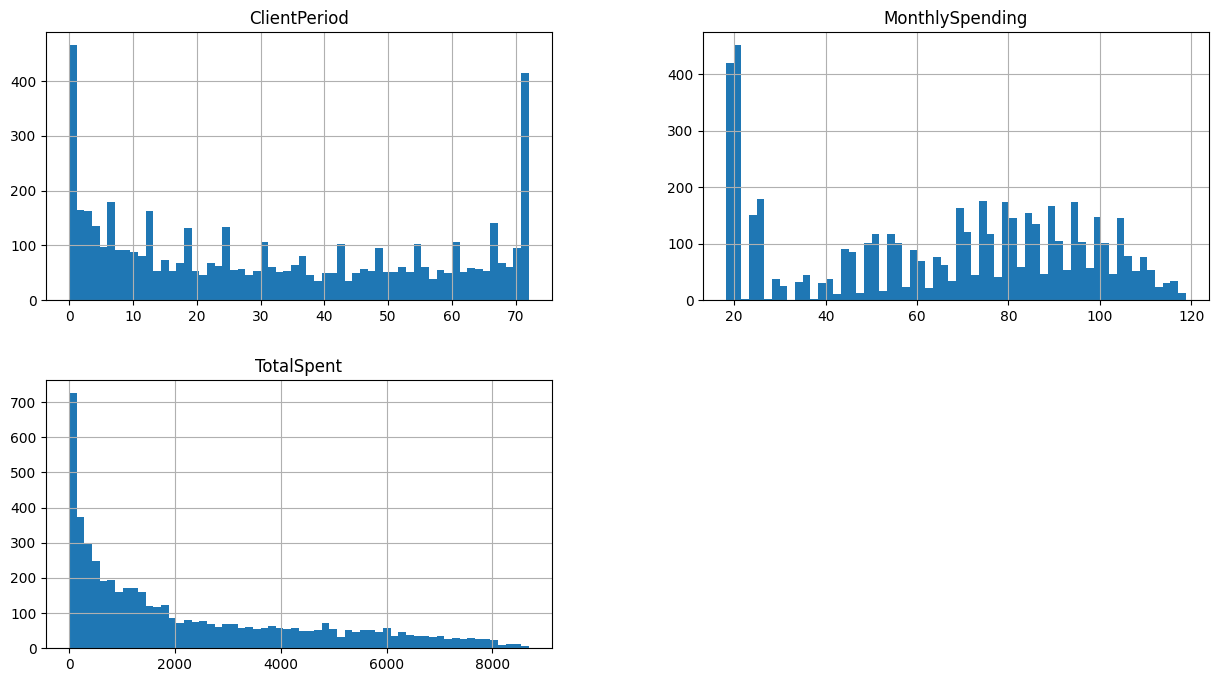

In [ ]:
# 1
# Гистограммы для численных признаков
data[num_cols].hist(figsize=(15, 8), bins=60)
plt.show()

In [ ]:
# Из гистограмм выше предполагаю следущее:
# 1. много значений Client Period = 0 => Много новых пользователей (возможно у компании сейчас сильная рекламная программа)
# 2. много значений Client Period = 70 => Много пользователей "старичков"
# 3. много значений Montly Spending = +-20 (видимо самые выгодные тарифы стоят около 20)
# 4. много значений Total Spent = 0 (в связи с большим кол-вом новых пользователей)

In [ ]:
# 1.2
# Вывод кол-ва значений категориальных признаков
for i in cat_cols:
  display(data[i].value_counts())
  print()

,count
Sex,
Male,2655
Female,2627


,count
IsSeniorCitizen,
0,4440
1,842


,count
HasPartner,
No,2705
Yes,2577


,count
HasChild,
No,3676
Yes,1606


,count
HasPhoneService,
Yes,4761
No,521


...

,count
HasOnlineTV,
No,2099
Yes,2042
No internet service,1141


,count
HasMovieSubscription,
No,2081
Yes,2060
No internet service,1141


,count
HasContractPhone,
Month-to-month,2920
Two year,1280
One year,1082


,count
IsBillingPaperless,
Yes,3148
No,2134


,count
PaymentMethod,
Electronic check,1786
Mailed check,1194
Bank transfer (automatic),1159
Credit card (automatic),1143


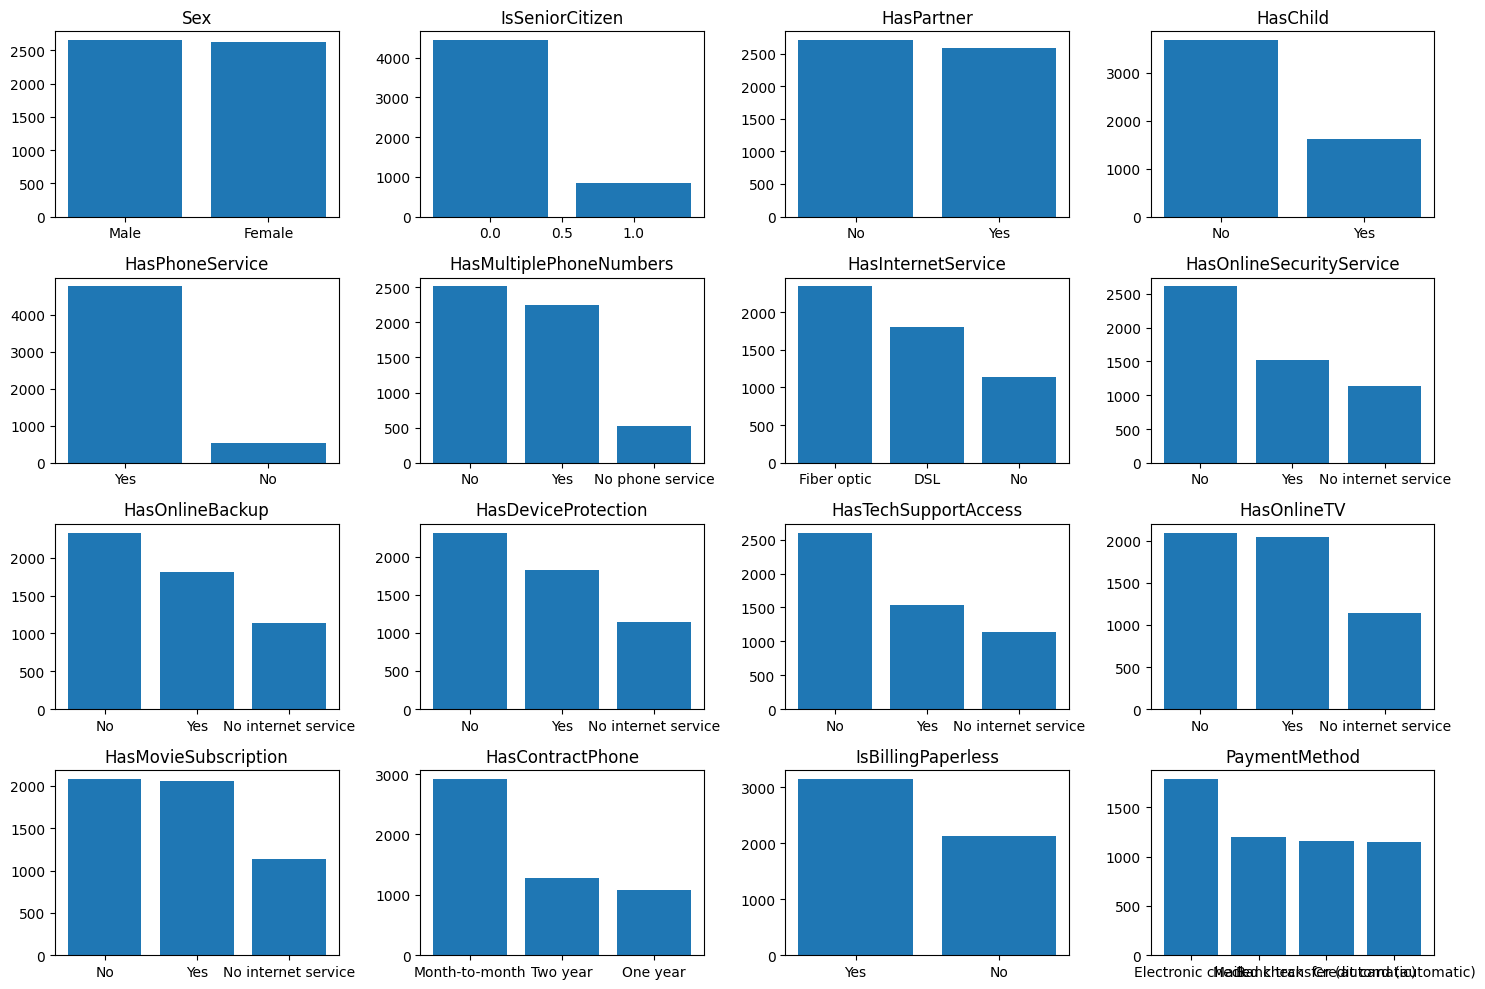

In [ ]:
# 1.3(1)
# Графики распределения признаков в категориальных колонках (через plt.bar()):
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(15, 10))
for col_name, ax in zip(cat_cols, axes.flatten()):
  counts = data[col_name].value_counts()
  ax.bar(counts.index, counts.values)
  ax.set_title(col_name)

plt.tight_layout()
plt.show()

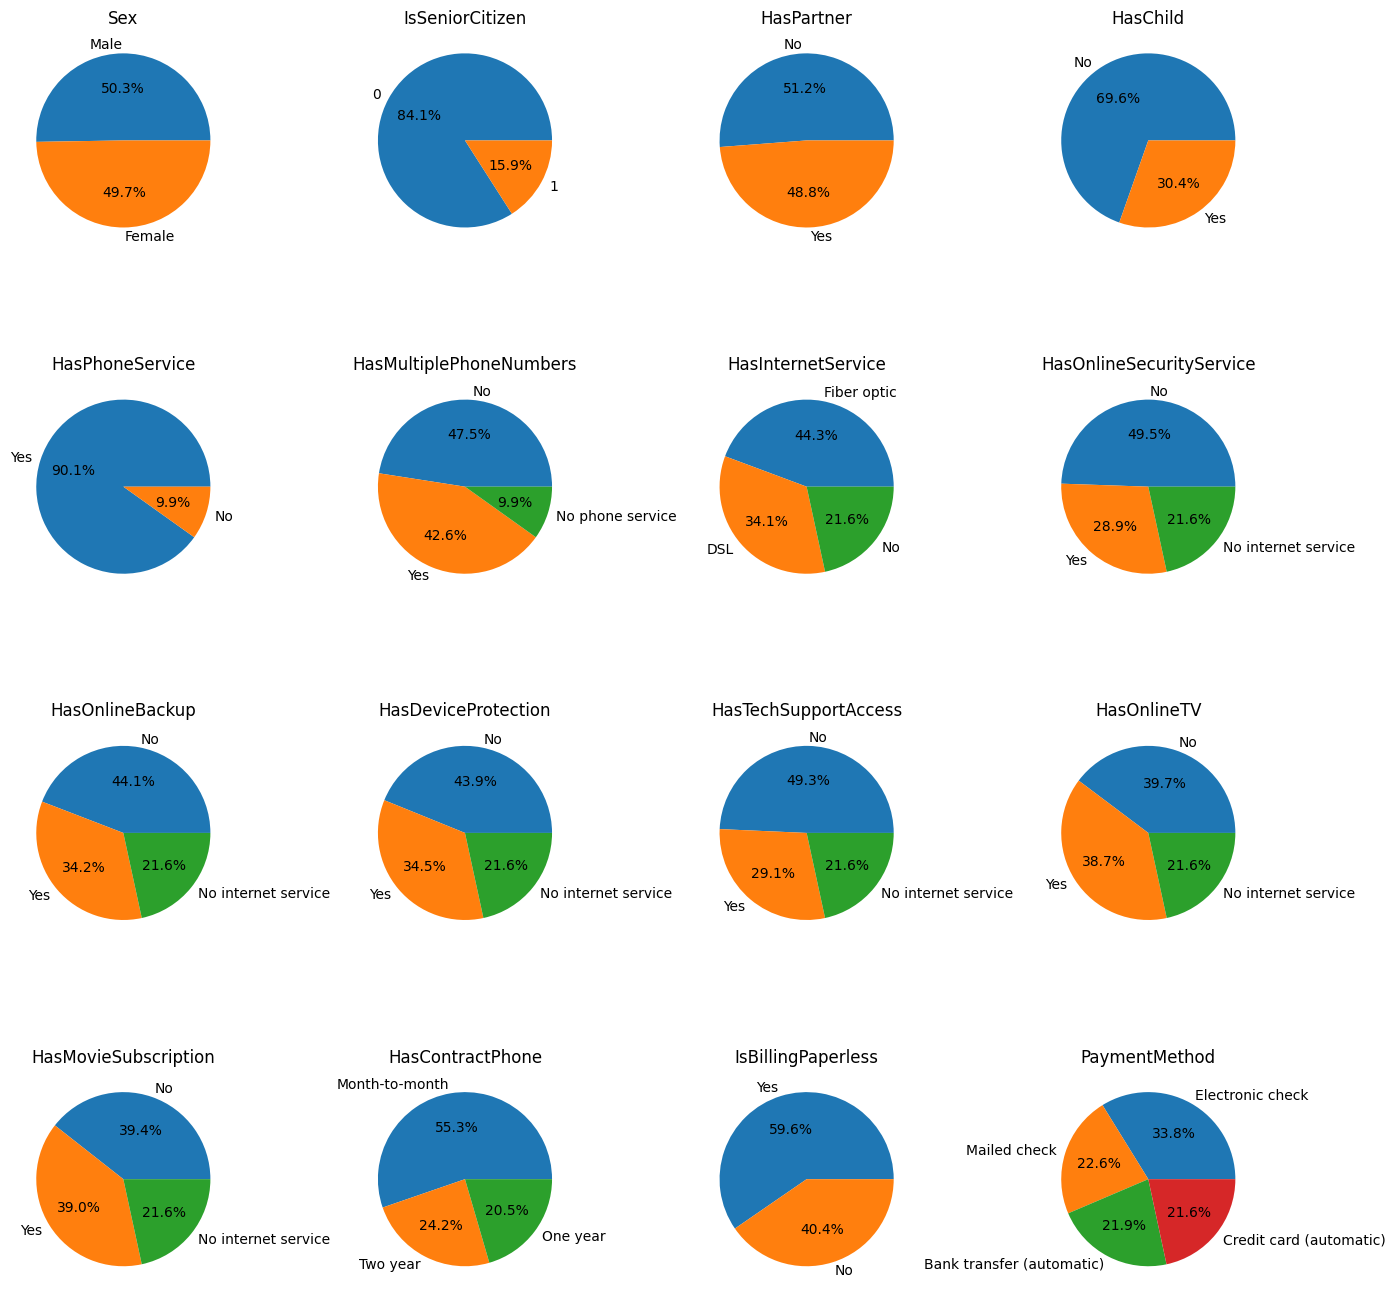

In [ ]:
# 1.3(2)
# Графики распределения признаков в категориальных колонках (через plt.pie(), для тренировки):
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(14, 14))
for col_name, ax in zip(cat_cols, axes.flatten()):
  count = data[col_name].value_counts()
  ax.pie(count.values, labels=count.index, autopct='%1.1f%%')
  ax.set_title(col_name)

plt.tight_layout()
plt.show()

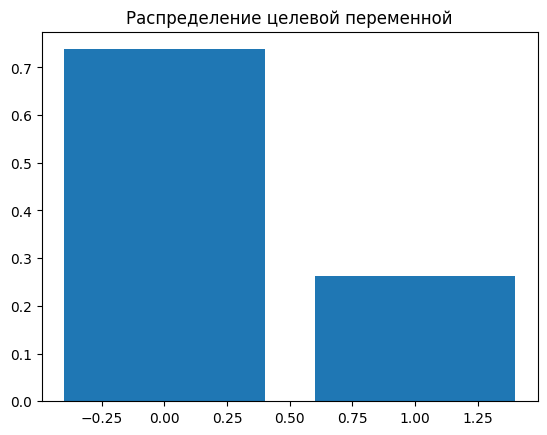

Доли классов:


,proportion
Churn,
0,0.737978
1,0.262022


In [ ]:
# 2
# Распределение целевой переменной
c = (data[target_col]).value_counts(normalize=True)
plt.bar(c.index, c.values)
plt.title('Распределение целевой переменной')
plt.show()
print('Доли классов:')
display(c)

# Видим, что классы таргета несблансированны

<Axes: xlabel='Churn', ylabel='ClientPeriod'>

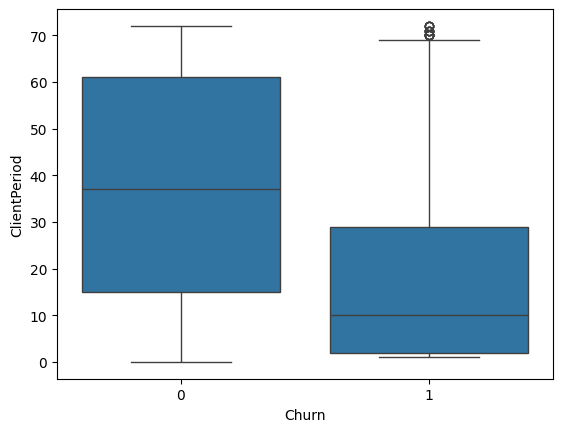

In [ ]:
# 3.1
# Построим график показывающий кто уходит чаще новые пользователи или старые?

sns.boxplot(x=data[target_col], y=data['ClientPeriod'], data=data)

In [ ]:
# 3.2
# Полноценный HTML-отчет, который делает аналитику датасета за нас

from ydata_profiling import ProfileReport
profile = ProfileReport(data, title="Telecom Churn EDA", minimal=True)

profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 20/20 [00:00<00:00, 45.99it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# 3.3 Интерактивный Scatter Plot

import plotly.express as px
import plotly.express as px

fig = px.scatter(data,
                 x='ClientPeriod',
                 y='TotalSpent',
                 color='Churn',
                 opacity=0.6,
                 title='Связь срока жизни, трат и оттока')

fig.show()

## Применение линейных моделей

In [ ]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score

In [ ]:
# OHE для категорильальных признаков

data_preproces = pd.get_dummies(data, columns=cat_cols, drop_first=True, dtype=int)
data_preproces.head()

,ClientPeriod,MonthlySpending,TotalSpent,Churn,Sex_Male,IsSeniorCitizen_1,HasPartner_Yes,HasChild_Yes,HasPhoneService_Yes,HasMultiplePhoneNumbers_No phone service,...,HasOnlineTV_No internet service,HasOnlineTV_Yes,HasMovieSubscription_No internet service,HasMovieSubscription_Yes,HasContractPhone_One year,HasContractPhone_Two year,IsBillingPaperless_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,55,19.50,1026.35,0,1,0,1,1,1,0,...,1,0,1,0,1,0,0,0,0,1
1,72,25.85,1872.20,0,1,0,1,0,1,0,...,1,0,1,0,0,1,0,1,0,0
2,1,75.90,75.90,1,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
3,32,79.30,2570.00,0,0,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,1
4,60,115.25,6758.45,0,0,0,1,1,1,0,...,0,1,0,1,0,1,0,1,0,0


In [ ]:
# разделяем данные
X = data_preproces.drop('Churn', axis=1)
y = data_preproces['Churn']
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=42)

In [ ]:
# создаем pipeline
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
pipe_params = {'logisticregression__C': [100, 10, 1, 0.1, 0.01, 0.001]}

In [ ]:
# применяем GridSearchCV внутри pipeline
params = {'C': [100, 10, 1, 0.1, 0.01, 0.001]}

cv_searcher_pipe = GridSearchCV(estimator=pipe,
                          param_grid=pipe_params, cv=5,
                          scoring='roc_auc')

cv_searcher_pipe.fit(X_train, y_train)

print(cv_searcher_pipe.best_params_)
print(cv_searcher_pipe.best_score_)

{'logisticregression__C': 10}
0.850546563561639


In [ ]:
# получаем результат
val_pred_pipe = cv_searcher_pipe.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, val_pred_pipe)
print(roc_auc)

0.8250343870508192


Лучшее качество которое удалось получить: 0.825

## Применение градиентного бустинга

In [ ]:
from catboost import CatBoostClassifier

In [ ]:
# разделяем данные
X = data.drop('Churn', axis=1)
y = data['Churn']
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=42)

# создаем и обучаем модель
cat_boost_model = CatBoostClassifier(eval_metric='AUC',
                                     random_seed=42,
                                     iterations=500,
                                     learning_rate=0.02,
                                     depth=4,
                                     verbose=False)

cat_boost_model.fit(X_train, y_train, cat_features=cat_cols)

# получаем предсказания и roc-auc
val_pred_cat = cat_boost_model.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, val_pred_cat)
print(roc_auc)

0.828310367695822


*   Лучшее качество ROC-AUC: 0.828310367695822
*   Параметры: eval_metric='AUC',
                                     random_seed=42,
                                     iterations=500,
                                     learning_rate=0.02,
                                     depth=4,
                                     verbose=False


# Предсказания

In [ ]:
best_model = cat_boost_model

In [ ]:
X_test = pd.read_csv('./test.csv')
submission = pd.read_csv('./submission.csv')

submission['Churn'] = best_model.predict_proba(X_test)[:, 1]
submission.to_csv('./my_submission.csv', index=False)

ИТОГОВЫЙ ROC-AUC на KAGGLE: 0.8523